In [162]:
import re
import warnings

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
from gensim.models import Word2Vec
from nltk.corpus import stopwords
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from tensorflow.keras.datasets import imdb
from wordcloud import WordCloud
from xgboost import XGBClassifier

import numpy as np

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")


def ensure_stop_words_downloaded():
    try:
        nltk.data.find("corpora/stopwords")
    except LookupError:
        nltk.download("stopwords")


def ensure_punkt_tab_downloaded():
    try:
        nltk.data.find("tokenizers/punkt")
    except LookupError:
        nltk.download("punkt")


ensure_stop_words_downloaded()
ensure_punkt_tab_downloaded()

## Phase 1 : Exploration et Préparation

### 1.1 - Chargement et exploration des données
- Chargez un corpus de critiques
- Explorez la structure : nombre de données, label distribution
- Analysez la longueur des critiques
- Vérifiez l'équilibre des classes

In [140]:
(X_train_idx, y_train), (X_test_idx, y_test) = imdb.load_data(num_words=10000)

word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}


def decode_review(encoded_review):
    return " ".join([reverse_word_index.get(i - 3, "?") for i in encoded_review])


X_train_text = [decode_review(review) for review in X_train_idx]
X_test_text = [decode_review(review) for review in X_test_idx]

df_train = pd.DataFrame({"review": X_train_text, "sentiment": y_train})
df_test = pd.DataFrame({"review": X_test_text, "sentiment": y_test})

df = pd.concat([df_train, df_test], ignore_index=True)

print(f"Dimensions du DataFrame : {df.shape[0]} lignes et {df.shape[1]} colonnes.")

print("\n5 premières lignes :")
print(df.head())

Dimensions du DataFrame : 50000 lignes et 2 colonnes.

5 premières lignes :
                                              review  sentiment
0  ? this film was just brilliant casting locatio...          1
1  ? big hair big boobs bad music and a giant saf...          0
2  ? this has to be one of the worst films of the...          0
3  ? the ? ? at storytelling the traditional sort...          1
4  ? worst mistake of my life br br i picked this...          0


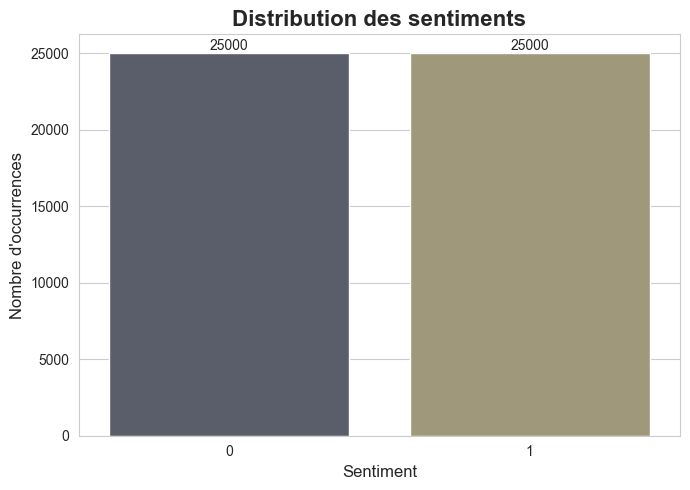

In [141]:
def display_barplot(x, y, title, xlabel, ylabel):
    plt.figure(figsize=(7, 5))

    barplot = sns.barplot(x=x, y=y, palette="cividis")

    plt.title(title, fontsize=16, fontweight="bold")
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)

    for container in barplot.containers:
        barplot.bar_label(container)

    plt.tight_layout()
    plt.show()


sentiments = df["sentiment"].value_counts()
display_barplot(
    x=sentiments.index,
    y=sentiments.values,
    title="Distribution des sentiments",
    xlabel="Sentiment",
    ylabel="Nombre d'occurrences",
)

Dataset équilibré.

### 1.2 - Nettoyage des données
- Appliquez le nettoyage de texte complet (exercice 1)
- Normalisez les longueurs
- Vérifiez qu'il n'y a pas de missing values
- Analysez la qualité des données

In [142]:
STOP_WORDS = set(stopwords.words("english"))
STOP_WORDS.add("br")


def preprocessor(sentence: str) -> str:
    sentence = sentence.lower()
    sentence = re.sub(r"[^\w\s\']", "", sentence)
    sentence_tokenized = sentence.split()
    sentence = " ".join(
        [token for token in sentence_tokenized if token not in STOP_WORDS]
    )
    return sentence


def enriched_df(df):
    df["review_cleaned"] = df["review"].apply(lambda x: preprocessor(x))
    df["review_tokenized"] = df["review_cleaned"].apply(lambda x: x.split())
    df["length"] = df["review_cleaned"].apply(lambda x: len(x))
    df["count_token"] = df["review_tokenized"].apply(lambda x: len(x))
    return df


enriched_df(df)
df = df.sample(1_000)
df.head(5)

,review,sentiment,review_cleaned,review_tokenized,length,count_token
33553,? never mind the serious logic gaps never mind...,0,never mind serious logic gaps never mind clich...,"[never, mind, serious, logic, gaps, never, min...",1186,173
9427,? overall this movie is dreadful and should ha...,0,overall movie dreadful never made one problems...,"[overall, movie, dreadful, never, made, one, p...",634,95
199,? this movie is about ? a gladiator who is bro...,0,movie gladiator brought back dead gladiator mu...,"[movie, gladiator, brought, back, dead, gladia...",501,76
12447,? drawing restraint 9 ? matthew barney br br h...,0,drawing restraint 9 matthew barney know middle...,"[drawing, restraint, 9, matthew, barney, know,...",2285,346
39489,? this story had a good plot to it about four ...,0,story good plot four elderly men share deadly ...,"[story, good, plot, four, elderly, men, share,...",509,81


In [143]:
def analyse_missing_date(df: pd.DataFrame) -> pd.DataFrame:
    missing = df.isnull().sum()
    missing_pct = 100 * missing / len(df)
    df_missing = pd.DataFrame(
        {
            "Colonnes": missing.index,
            "Valeurs manquantes": missing.values,
            "Pourcentages": missing_pct.values,
        }
    )
    df_missing = df_missing[df_missing["Valeurs manquantes"] > 0].sort_values(
        "Pourcentages", ascending=False
    )
    return df_missing


missing_data = analyse_missing_date(df)
if len(missing_data) > 0:
    missing_data.head(len(missing_data))
else:
    print("Pas de valeur manqante")

Pas de valeur manqante


In [144]:
df_without_duplicates = df.drop_duplicates(subset=["review_cleaned"])
print(f"Nombre de doublons : {len(df) - len(df_without_duplicates)}")

df = df_without_duplicates.copy()

Nombre de doublons : 1


### 1.3 - Analyse exploratoire
- Statistiques par classe
- Mots les plus fréquents positifs vs négatifs
- Word clouds par sentiment
- Longueur moyenne par classe

In [145]:
df_0 = df[df["sentiment"] == 0]
df_1 = df[df["sentiment"] == 1]

print("Statistiques descriptives label 0 :")
print(df_0[["length", "count_token"]].describe())

print("\nStatistiques descriptives label 1 :")
print(df_1[["length", "count_token"]].describe())

Statistiques descriptives label 0 :
            length  count_token
count   498.000000   498.000000
mean    677.240964   102.200803
std     494.451030    73.217296
min      81.000000    13.000000
25%     390.000000    59.000000
50%     515.500000    80.000000
75%     798.750000   118.750000
max    3365.000000   480.000000

Statistiques descriptives label 1 :
            length  count_token
count   501.000000   501.000000
mean    733.682635   109.131737
std     543.213337    79.467721
min      67.000000     9.000000
25%     389.000000    57.000000
50%     536.000000    80.000000
75%     931.000000   141.000000
max    3464.000000   492.000000


In [146]:
count_vectorizer_0 = CountVectorizer()
X_0 = count_vectorizer_0.fit_transform(df_0["review_cleaned"])
features_count_0 = pd.DataFrame(
    {
        "features": count_vectorizer_0.get_feature_names_out(),
        "count": np.asarray(X_0.sum(axis=0)).flatten(),
    }
)

count_vectorizer_1 = CountVectorizer()
X_1 = count_vectorizer_1.fit_transform(df_1["review_cleaned"])
features_count_1 = pd.DataFrame(
    {
        "features": count_vectorizer_1.get_feature_names_out(),
        "count": np.asarray(X_1.sum(axis=0)).flatten(),
    }
)

print("Top 10 occurrence mots négatifs :")
print(features_count_0.nlargest(10, "count"))

print("\nTop 10 occurrence mots positifs :")
print(features_count_1.nlargest(10, "count"))

Top 10 occurrence mots négatifs :
     features  count
3874    movie   1010
2323     film    784
4110      one    472
3468     like    463
6580    would    311
528       bad    300
2089     even    290
2625     good    264
4733   really    254
6002     time    239

Top 10 occurrence mots positifs :
     features  count
2546     film    782
4231    movie    778
4477      one    540
3783     like    391
6503     time    280
2869     good    268
5600      see    253
6127    story    251
6980     well    239
2909    great    234


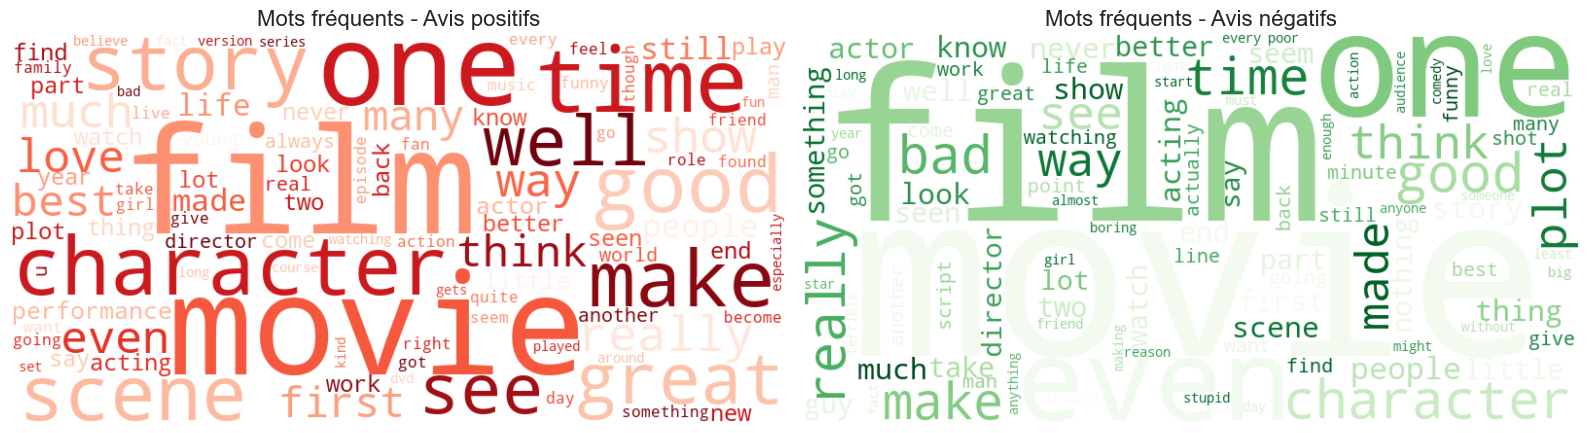

In [147]:
wordcloud_0 = WordCloud(
    width=800, height=400, background_color="white", colormap="Greens", max_words=100
).generate(df_0["review_cleaned"].str.cat(sep=" "))

wordcloud_1 = WordCloud(
    width=800, height=400, background_color="white", colormap="Reds", max_words=100
).generate(df_1["review_cleaned"].str.cat(sep=" "))

plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_1, interpolation="bilinear")
plt.axis("off")
plt.title("Mots fréquents - Avis positifs", fontsize=16)

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_0, interpolation="bilinear")
plt.axis("off")
plt.title("Mots fréquents - Avis négatifs", fontsize=16)

plt.tight_layout()
plt.show()

## Phase 2 : Feature Engineering

### 2.1 - Vectorisation (rappel exercice 2)
- Appliquez TF-IDF Vectorizer
- Paramètres : max_features=5000, min_df=2
- Normalisez avec L2

In [148]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 1),
    max_features=5000,
    min_df=2,
    norm="l2",
)

X = tfidf.fit_transform(df["review_cleaned"])

### 2.2 - Features Word2Vec (rappel exercice 3)
- Entraînez Word2Vec sur le corpus
- Générez des embeddings de documents (moyenne)
- Approche alternative à TF-IDF

In [149]:
w2v = Word2Vec(
    sentences=df["review_tokenized"],
    vector_size=300,
    window=5,
    min_count=1,
    workers=4,
    seed=RANDOM_STATE,
)


def get_document_embedding(tokens, model):
    valid_tokens = [t for t in tokens if t in model.wv]
    if not valid_tokens:
        return np.zeros(model.vector_size)
    return np.mean([model.wv[t] for t in valid_tokens], axis=0)


doc_embeddings = [
    get_document_embedding(sentence, w2v) for sentence in df["review_cleaned"]
]
doc_embeddings = np.array(doc_embeddings)

### 2.3 - Feature Selection
- Analysez l'importance des features
- Testez différentes dimensionnalités
- Utilisez SelectKBest si nécessaire

In [150]:
K_VALUES = [100, 300, 500, 1000, 2000, 5000]


def split_dataset(X, y):
    return train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)


def compute_feature_importance(model, feature_names):
    selector = model.named_steps["selector"]
    classifier = model.named_steps["classifier"]
    selected_features = np.array(feature_names)[selector.get_support()]
    coef = classifier.coef_[0]
    importance_df = pd.DataFrame(
        {"feature": selected_features, "coefficient": coef, "importance": np.abs(coef)}
    )
    return importance_df.sort_values("importance", ascending=False)


def evaluate_dimension_sizes(X_train, X_test, y_train, y_test, k_values):
    results = []
    for k in k_values:
        pipeline = Pipeline(
            [
                ("vectorizer", tfidf),
                ("selector", SelectKBest(score_func=chi2, k=k)),
                ("classifier", LogisticRegression(max_iter=1000)),
            ]
        )
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        results.append(
            {
                "k": k,
                "accuracy": accuracy_score(y_test, y_pred),
                "f1_score": f1_score(y_test, y_pred, average="macro"),
            }
        )
    return pd.DataFrame(results)


def train_final_model(X_train, y_train, best_k):
    pipeline = Pipeline(
        [
            ("vectorizer", tfidf),
            ("selector", SelectKBest(score_func=chi2, k=best_k)),
            ("classifier", LogisticRegression(max_iter=1000)),
        ]
    )
    pipeline.fit(X_train, y_train)
    return pipeline


def run_feature_selection_experiment(X, y, feature_names):
    print("Split dataset...")
    X_train, X_test, y_train, y_test = split_dataset(X, y)

    print("Testing dimensionality...")
    results = evaluate_dimension_sizes(X_train, X_test, y_train, y_test, K_VALUES)

    print("\nDimension results:")
    print(results)

    best_k = int(results.sort_values("f1_score", ascending=False).iloc[0]["k"])

    print(f"\nBest k selected: {best_k}")

    print("\nTraining final model...")
    model = train_final_model(X_train, y_train, best_k)

    y_pred = model.predict(X_test)

    print("\nFinal performance")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred, average="macro"))

    print("\nComputing feature importance...")
    importance_df = compute_feature_importance(model, feature_names)

    print("\nTop 10 features")
    print(importance_df.head(10))

    return model, results, importance_df


model, results, importance = run_feature_selection_experiment(
    df["review_cleaned"], df["sentiment"], tfidf.get_feature_names_out()
)

Split dataset...
Testing dimensionality...

Dimension results:
      k  accuracy  f1_score
0   100     0.765  0.763671
1   300     0.805  0.804761
2   500     0.775  0.774724
3  1000     0.825  0.824785
4  2000     0.855  0.854967
5  5000     0.830  0.829847

Best k selected: 2000

Training final model...

Final performance
Accuracy: 0.855
F1-score: 0.854967367657723

Computing feature importance...

Top 10 features
           feature  coefficient  importance
154         austin    -2.387272    2.387272
1980       worried    -1.691602    1.691602
769           goes     1.419751    1.419751
1691  successfully    -1.387879    1.387879
188            bay     1.351572    1.351572
1015        loving     1.340589    1.340589
1100     miserable    -1.324152    1.324152
151       attended    -1.312583    1.312583
1264         picks    -1.179268    1.179268
1271         plain    -1.158640    1.158640


## Phase 3 : Modélisation Avancée

### 3.1 - Modèle 1 : Logistic Regression avec optimisation
- Tuning avec GridSearchCV
- Paramètres : C, penalty, solver
- Baseline pour comparaison

In [151]:
K_BEST = 100


def build_model_lr():
    return Pipeline(
        steps=[
            ("vectorizer", tfidf),
            ("selector", SelectKBest(score_func=chi2, k=K_BEST)),
            (
                "classifier",
                LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
            ),
        ]
    )


def build_param_grid_lr():
    return {
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__penalty": ["l1", "l2"],
        "classifier__solver": ["liblinear", "saga"],
        "classifier__class_weight": [None, "balanced"],
    }


def build_grid_search(model, param_grid):
    return GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="f1_macro",
        n_jobs=-1,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        verbose=1,
        return_train_score=True,
    )


def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print("\nFinal performance")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred, average="macro"))


def run_experiment(X, y, model, param_grid):
    print("Splitting dataset...")
    X_train, X_test, y_train, y_test = split_dataset(X, y)

    print("Building GridSearch...")
    grid_search = build_grid_search(model, param_grid)

    print("Training GridSearch...")
    grid_search.fit(X_train, y_train)

    print("\nBest parameters:")
    print(grid_search.best_params_)

    best_model = grid_search.best_estimator_

    evaluate_model(best_model, X_test, y_test)

    return best_model


best_model_lr = run_experiment(
    X=df["review_cleaned"],
    y=df["sentiment"],
    model=build_model_lr(),
    param_grid=build_param_grid_lr(),
)

Splitting dataset...
Building GridSearch...
Training GridSearch...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best parameters:
{'classifier__C': 10, 'classifier__class_weight': None, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

Final performance
Accuracy: 0.79
F1-score: 0.7896634615384616


### 3.2 - Modèle 2 : SVM
- Kernel tuning : linear, rbf
- Paramètres : C, gamma
- Comparaison avec Logistic Regression

In [152]:
def build_model_svc():
    return Pipeline(
        steps=[
            ("vectorizer", tfidf),
            ("selector", SelectKBest(score_func=chi2, k=K_BEST)),
            (
                "classifier",
                SVC(random_state=RANDOM_STATE, kernel="linear", probability=True),
            ),
        ]
    )


def build_param_grid_svc():
    return {
        "classifier__C": [
            0.01,
            0.1,
            1,
            10,
            100,
        ],
        # "classifier__kernel": ["linear", "rbf", "poly"],
        "classifier__gamma": [
            "scale",
            "auto",
            0.01,
            0.1,
            1,
        ],
        "classifier__class_weight": [None, "balanced"],
    }


best_model_svc = run_experiment(
    X=df["review_cleaned"],
    y=df["sentiment"],
    model=build_model_svc(),
    param_grid=build_param_grid_svc(),
)

Splitting dataset...
Building GridSearch...
Training GridSearch...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters:
{'classifier__C': 10, 'classifier__class_weight': None, 'classifier__gamma': 'scale'}

Final performance
Accuracy: 0.78
F1-score: 0.7794486215538847


### 3.3 - Modèle 3 : Random Forest
- Tuning : n_estimators, max_depth, min_samples_split
- Feature importance
- Out-of-bag validation

In [153]:
def build_model_rf():
    return Pipeline(
        steps=[
            ("vectorizer", tfidf),
            ("selector", SelectKBest(score_func=chi2, k=K_BEST)),
            (
                "classifier",
                RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
            ),
        ]
    )


def build_param_grid_rf():
    return {
        "classifier__n_estimators": [
            100,
            300,
            # 500,
        ],
        "classifier__max_depth": [
            None,
            10,
            20,
            # 50,
        ],
        "classifier__min_samples_split": [
            2,
            5,
            # 10,
        ],
        # "classifier__min_samples_leaf": [1, 2, 4],
        # "classifier__max_features": ["sqrt", "log2"],
        "classifier__class_weight": [None, "balanced"],
    }


best_model_rf = run_experiment(
    X=df["review_cleaned"],
    y=df["sentiment"],
    model=build_model_rf(),
    param_grid=build_param_grid_rf(),
)

Splitting dataset...
Building GridSearch...
Training GridSearch...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters:
{'classifier__class_weight': None, 'classifier__max_depth': 20, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}

Final performance
Accuracy: 0.765
F1-score: 0.7649941248531213


### 3.4 - Modèle 4 : Ensemble Learning
- Voting Classifier (LR + SVM + RF)
- Stacking avec meta-learner
- Bagging/Boosting

In [154]:
def build_model_voting():
    estimators = [
        ("lr", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ("svc", SVC(random_state=RANDOM_STATE, kernel="linear", probability=True)),
        (
            "rf",
            RandomForestClassifier(
                n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
            ),
        ),
    ]
    return Pipeline(
        steps=[
            ("vectorizer", tfidf),
            ("selector", SelectKBest(score_func=chi2, k=K_BEST)),
            ("classifier", VotingClassifier(estimators=estimators, voting="soft")),
        ]
    )


# Le StackingClassifier apprend un meta-modèle à partir des prédictions des modèles de base.
def build_model_stacking():
    base_models = [
        ("lr", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ("svm", SVC(kernel="linear", probability=True, random_state=RANDOM_STATE)),
        (
            "rf",
            RandomForestClassifier(
                n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1
            ),
        ),
    ]

    meta_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

    return Pipeline(
        steps=[
            ("vectorizer", tfidf),
            ("selector", SelectKBest(score_func=chi2, k=K_BEST)),
            (
                "stack",
                StackingClassifier(
                    estimators=base_models,
                    final_estimator=meta_model,
                    cv=5,
                    n_jobs=-1,
                ),
            ),
        ]
    )


# Le BaggingClassifier entraîne plusieurs versions du même modèle sur des samples bootstrap.
def build_model_bagging():
    estimator = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    return Pipeline(
        steps=[
            ("vectorizer", tfidf),
            ("selector", SelectKBest(score_func=chi2, k=K_BEST)),
            (
                "bag",
                BaggingClassifier(
                    estimator=estimator,
                    n_estimators=100,
                    max_samples=0.8,
                    max_features=0.8,
                    bootstrap=True,
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


# Le boosting entraîne des modèles séquentiellement.
def build_model_xgboost():
    return Pipeline(
        steps=[
            ("vectorizer", tfidf),
            ("selector", SelectKBest(score_func=chi2, k=K_BEST)),
            (
                "xgb",
                XGBClassifier(
                    objective="binary:logistic",
                    eval_metric="logloss",
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=6,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )


def train_and_evaluate_models(X, y):
    X_train, X_test, y_train, y_test = split_dataset(X, y)

    models = {
        "Voting": build_model_voting(),
        "Stacking": build_model_stacking(),
        "Bagging": build_model_bagging(),
        "XGBoost": build_model_xgboost(),
    }

    results = {}

    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        results[name] = {
            "accuracy": accuracy_score(y_test, y_pred),
            "f1_score": f1_score(y_test, y_pred, average="macro"),
        }

    return results


scores = train_and_evaluate_models(df["review_cleaned"], df["sentiment"])

print("\nResults:")
for model_name, metrics in scores.items():
    print(
        f"{model_name}: Accuracy={metrics['accuracy']:.4f}, F1={metrics['f1_score']:.4f}"
    )

Training Voting...
Training Stacking...
Training Bagging...
Training XGBoost...

Results:
Voting: Accuracy=0.7850, F1=0.7849
Stacking: Accuracy=0.8000, F1=0.8000
Bagging: Accuracy=0.7550, F1=0.7536
XGBoost: Accuracy=0.7850, F1=0.7850


## Phase 4 : Validation et Optimisation

### 4.1 - Validation Croisée
- K-Fold CV (k=5)
- Stratified CV pour données déséquilibrées
- Métriques : accuracy, F1, AUC

In [155]:
def evaluate_models_cv(X, y, models_dict, scoring):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    cv_results = {}

    for name, model in models_dict.items():
        print(f"\nTraining and evaluating {name}...")
        scores = cross_validate(
            model,
            X,
            y,
            cv=skf,
            scoring=scoring,
            return_train_score=False,
            n_jobs=-1,
        )

        results_summary = {
            metric: {
                "mean": np.mean(scores[f"test_{metric}"]),
                "std": np.std(scores[f"test_{metric}"]),
                "scores": scores[f"test_{metric}"],
            }
            for metric in scoring
        }

        cv_results[name] = results_summary

        for metric in scoring:
            print(
                f"  {metric} moyenne: {results_summary[metric]['mean']:.4f} (+/- {results_summary[metric]['std']:.4f})"
            )

    summary_data = []
    for model_name, metrics in cv_results.items():
        row = {"model": model_name}
        for metric in scoring:
            row[f"{metric}_mean"] = metrics[metric]["mean"]
            row[f"{metric}_std"] = metrics[metric]["std"]
        summary_data.append(row)

    summary_df = pd.DataFrame(summary_data).sort_values(
        by="f1_macro_mean", ascending=False
    )

    return cv_results, summary_df


models = {
    "Logistic Regression": best_model_lr,
    "SVM (linear)": best_model_svc,
    "Random Forest": best_model_rf,
    "Voting": build_model_voting(),
    "Stacking": build_model_stacking(),
    "Bagging": build_model_bagging(),
    "XGBoost": build_model_xgboost(),
}

scoring_metrics = ["accuracy", "f1_macro", "roc_auc"]

cv_results, summary_df = evaluate_models_cv(
    X=df["review_cleaned"],
    y=df["sentiment"],
    models_dict=models,
    scoring=scoring_metrics,
)


best_model_name = summary_df.iloc[0]["model"]
print(f"\n{'=' * 64}")
print(f"Meilleur modèle (f1_macro): {best_model_name}")
print(f"Score CV f1_macro moyen: {summary_df.iloc[0]['f1_macro_mean']:.4f}")


Training and evaluating Logistic Regression...
  accuracy moyenne: 0.7918 (+/- 0.0133)
  f1_macro moyenne: 0.7914 (+/- 0.0135)
  roc_auc moyenne: 0.8565 (+/- 0.0104)

Training and evaluating SVM (linear)...
  accuracy moyenne: 0.7878 (+/- 0.0188)
  f1_macro moyenne: 0.7871 (+/- 0.0190)
  roc_auc moyenne: 0.8564 (+/- 0.0114)

Training and evaluating Random Forest...
  accuracy moyenne: 0.7638 (+/- 0.0087)
  f1_macro moyenne: 0.7636 (+/- 0.0088)
  roc_auc moyenne: 0.8488 (+/- 0.0077)

Training and evaluating Voting...
  accuracy moyenne: 0.7668 (+/- 0.0087)
  f1_macro moyenne: 0.7666 (+/- 0.0087)
  roc_auc moyenne: 0.8539 (+/- 0.0074)

Training and evaluating Stacking...
  accuracy moyenne: 0.7738 (+/- 0.0135)
  f1_macro moyenne: 0.7737 (+/- 0.0135)
  roc_auc moyenne: 0.8530 (+/- 0.0075)

Training and evaluating Bagging...
  accuracy moyenne: 0.7658 (+/- 0.0203)
  f1_macro moyenne: 0.7641 (+/- 0.0206)
  roc_auc moyenne: 0.8439 (+/- 0.0167)

Training and evaluating XGBoost...
  accuracy 

### 4.2 - Hyperparameter Tuning
- GridSearchCV ou RandomizedSearchCV
- Pipeline ML complet (scaling + model)
- Cross-validation intégrée

### 4.3 - Gestion du déséquilibre
- Class weights si applicable
- SMOTE pour augmentation synthétique
- Métriques adaptées (F1, AUC plutôt qu'accuracy)

### 4.4 - Sélection du meilleur modèle
- Comparez tous les modèles
- Entraînez sur train set
- Évaluez sur test set

In [156]:
def evaluate_models_test_set(X, y, models_dict):
    X_train, X_test, y_train, y_test = split_dataset(X, y)

    results_dict = {}

    for name, model in models_dict.items():
        print(f"\nTraining and evaluating {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        try:
            y_proba = model.predict_proba(X_test)[:, 1]
        except AttributeError:
            y_proba = None

        metrics_dict = {}
        metrics_dict["accuracy"] = accuracy_score(y_test, y_pred)
        metrics_dict["precision"] = precision_score(y_test, y_pred)
        metrics_dict["recall"] = recall_score(y_test, y_pred)
        metrics_dict["f1_macro"] = f1_score(y_test, y_pred)
        if y_proba is not None:
            metrics_dict["roc_auc"] = roc_auc_score(y_test, y_proba)
        else:
            metrics_dict["roc_auc"] = np.nan  # impossible à calculer
        results_dict[name] = metrics_dict

        for metric, value in metrics_dict.items():
            print(f"  {metric}: {value:.4f}")

    summary_data = []
    for model_name, metrics in results_dict.items():
        row = {"model": model_name}
        for metric, value in metrics.items():
            row[f"{metric}_score"] = value
        summary_data.append(row)

    summary_df = (
        pd.DataFrame(summary_data)
        .sort_values(by="f1_macro_score", ascending=False)
        .reset_index(drop=True)
    )

    return results_dict, summary_df


models = {
    "Logistic Regression": best_model_lr,
    "SVM (linear)": best_model_svc,
    "Random Forest": best_model_rf,
    "Voting": build_model_voting(),
    "Stacking": build_model_stacking(),
    "Bagging": build_model_bagging(),
    "XGBoost": build_model_xgboost(),
}

results_dict, summary_df = evaluate_models_test_set(
    X=df["review_cleaned"],
    y=df["sentiment"],
    models_dict=models,
)


Training and evaluating Logistic Regression...
  accuracy: 0.7900
  precision: 0.7685
  recall: 0.8300
  f1_macro: 0.7981
  roc_auc: 0.8767

Training and evaluating SVM (linear)...
  accuracy: 0.7800
  precision: 0.7545
  recall: 0.8300
  f1_macro: 0.7905
  roc_auc: 0.8695

Training and evaluating Random Forest...
  accuracy: 0.7650
  precision: 0.7624
  recall: 0.7700
  f1_macro: 0.7662
  roc_auc: 0.8638

Training and evaluating Voting...
  accuracy: 0.7850
  precision: 0.7714
  recall: 0.8100
  f1_macro: 0.7902
  roc_auc: 0.8799

Training and evaluating Stacking...
  accuracy: 0.8000
  precision: 0.7941
  recall: 0.8100
  f1_macro: 0.8020
  roc_auc: 0.8794

Training and evaluating Bagging...
  accuracy: 0.7550
  precision: 0.7217
  recall: 0.8300
  f1_macro: 0.7721
  roc_auc: 0.8599

Training and evaluating XGBoost...
  accuracy: 0.7850
  precision: 0.7879
  recall: 0.7800
  f1_macro: 0.7839
  roc_auc: 0.8719


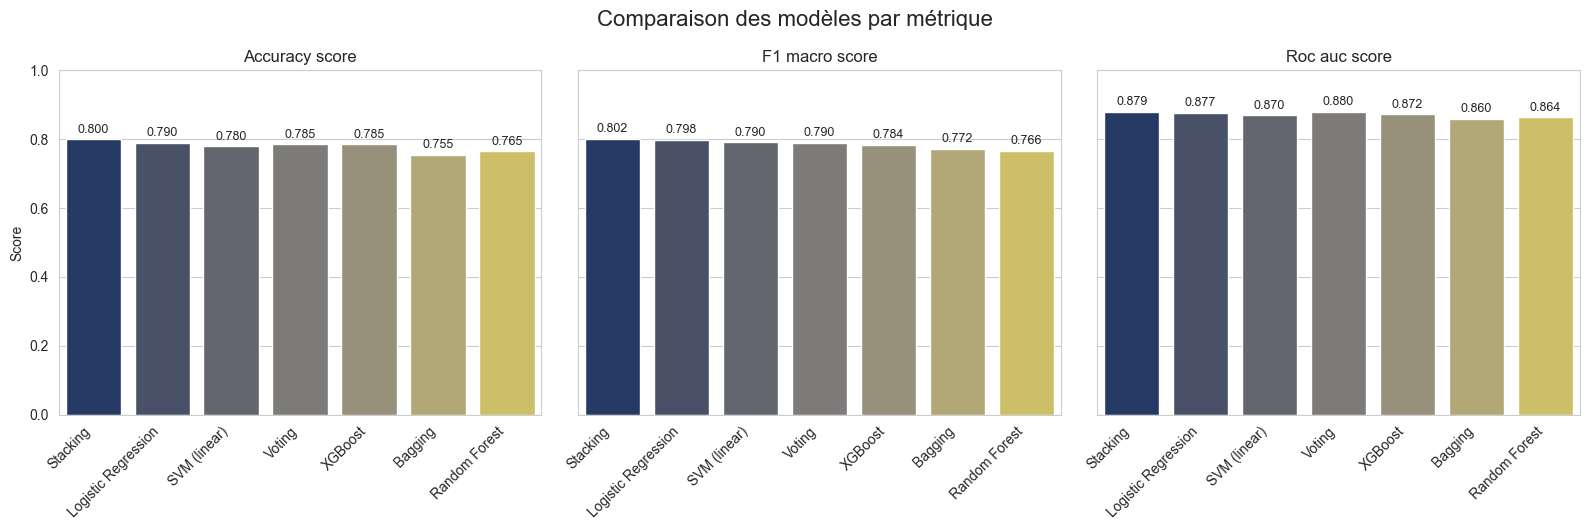

In [157]:
metrics = [
    "accuracy_score",
    # "precision_score",
    # "recall_score",
    "f1_macro_score",
    "roc_auc_score",
]

n_metrics = len(metrics)
fig, axes = plt.subplots(1, n_metrics, figsize=(16, 5), sharey=True)

for ax, metric in zip(axes, metrics):
    sns.barplot(x="model", y=metric, data=summary_df, palette="cividis", ax=ax)
    ax.set_title(metric.replace("_", " ").capitalize())
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    # Annoter les valeurs
    for i, score in enumerate(summary_df[metric]):
        ax.text(i, score + 0.01, f"{score:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.suptitle("Comparaison des modèles par métrique", y=1.05, fontsize=16)
plt.show()

## Phase 5 : Évaluation Complète

### 5.1 - Métriques globales
- Accuracy, Precision, Recall, F1 sur test set
- ROC-AUC score
- Matrice de confusion détaillée

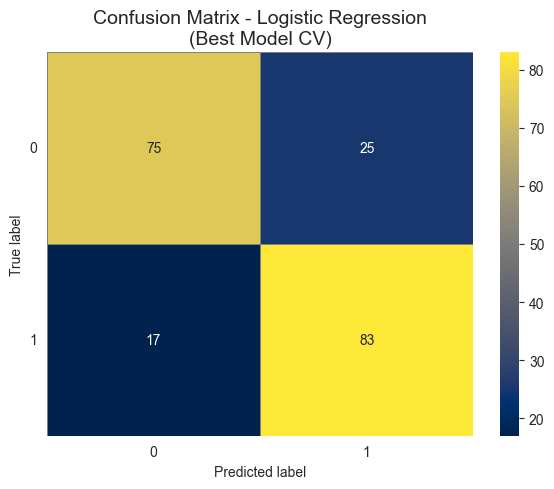

In [158]:
BEST_MODEL = models[best_model_name]


def display_confusion_matrix(X, y, model):
    X_train, X_test, y_train, y_test = split_dataset(X, y)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="cividis",
        xticklabels=np.unique(y),
        yticklabels=np.unique(y),
        cbar=True,
        linewidths=0.5,
        linecolor="gray",
    )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.title(f"Confusion Matrix - {best_model_name}\n(Best Model CV)", fontsize=14)
    plt.yticks(rotation=0)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


display_confusion_matrix(X=df["review_cleaned"], y=df["sentiment"], model=BEST_MODEL)

### 5.2 - Analyse des erreurs
- Faux positifs et faux négatifs
- Analysez 10 critiques mal classifiées
- Identifiez les patterns d'erreur

In [159]:
def get_misclassified_samples(X, y, model):
    X_train, X_test, y_train, y_test = split_dataset(X, y)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mask_fp = (y_test == 0) & (y_pred == 1)
    mask_fn = (y_test == 1) & (y_pred == 0)
    X_mis_fp = X_test[mask_fp]
    X_mis_fn = X_test[mask_fn]
    return X_mis_fp, X_mis_fn


X_mis_fp, X_mis_fn = get_misclassified_samples(
    X=df["review_cleaned"], y=df["sentiment"], model=BEST_MODEL
)

print(f"Nombre de samples mal classés : {len(X_mis_fp + X_mis_fn)}")
print(f"Nombre de faux positifs : {len(X_mis_fp)}")
print(f"Nombre de faux négatifs : {len(X_mis_fn)}")
print("\n10 Faux positifs :")
print(X_mis_fp.head(10))
print("\n10 Faux négatifs :")
print(X_mis_fn.head(10))

Nombre de samples mal classés : 42
Nombre de faux positifs : 25
Nombre de faux négatifs : 17

10 Faux positifs :
4878     saw film weekend impressed always beauty polis...
13609    contains spoilers british director j lee thomp...
38249    sex lives men sex lives several men involved d...
38264    hardly know year later mgm put norma mgm techn...
48085    quite impressed movie child eight nine gangste...
25480    film realism really get feeling screenwriter j...
1822     spoilers returning home capital rural celebrat...
13649    animation looks like done 30 seconds looks lik...
41163    especially love horrible movies first started ...
17132    movie entertaining enough due excellent perfor...
Name: review_cleaned, dtype: object

10 Faux négatifs :
31469    american exposed character good disappointed n...
19698    third final installment hanzo razor training e...
1655     great small film say small hundred guns firing...
31755    sometimes movie bad kind good movie made germa...
5872 

### 5.3 - Visualisations
- Confusion matrix (heatmap)
- ROC curve avec AUC
- Feature importance
- Précision-Recall curve

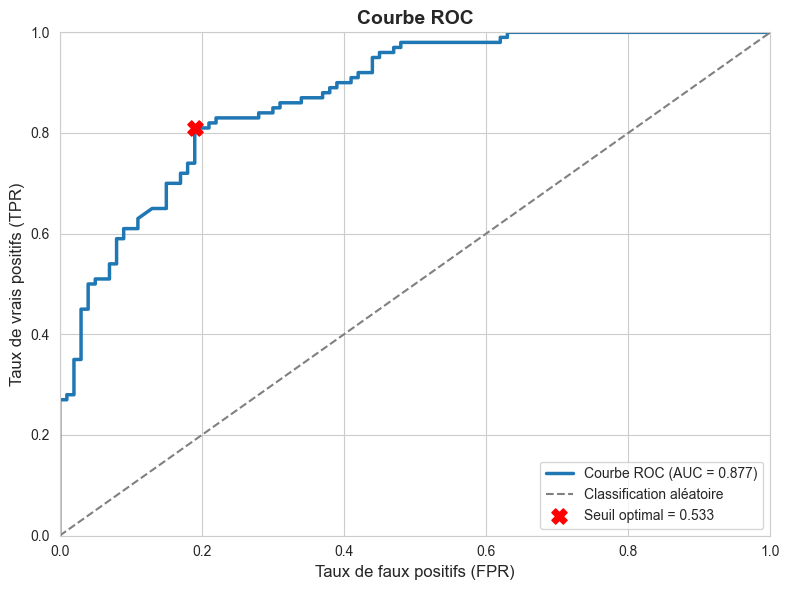

In [161]:
def display_roc_curve(X, y, model):
    X_train, X_test, y_train, y_test = split_dataset(X, y)
    model_fitted = model.fit(X_train, y_train)
    y_proba = model_fitted.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    youden_j = tpr - fpr
    optimal_idx = np.argmax(youden_j)
    optimal_threshold = thresholds[optimal_idx]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(
        fpr, tpr, color="#1f77b4", linewidth=2.5, label=f"Courbe ROC (AUC = {auc:.3f})"
    )
    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="gray",
        linewidth=1.5,
        label="Classification aléatoire",
    )
    ax.scatter(
        fpr[optimal_idx],
        tpr[optimal_idx],
        color="red",
        s=120,
        marker="X",
        label=f"Seuil optimal = {optimal_threshold:.3f}",
        zorder=3,
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title("Courbe ROC", fontsize=14, fontweight="bold")
    ax.set_xlabel("Taux de faux positifs (FPR)", fontsize=12)
    ax.set_ylabel("Taux de vrais positifs (TPR)", fontsize=12)
    ax.legend(loc="lower right", frameon=True)
    plt.tight_layout()
    plt.show()


display_roc_curve(df["review_cleaned"], df["sentiment"], BEST_MODEL)

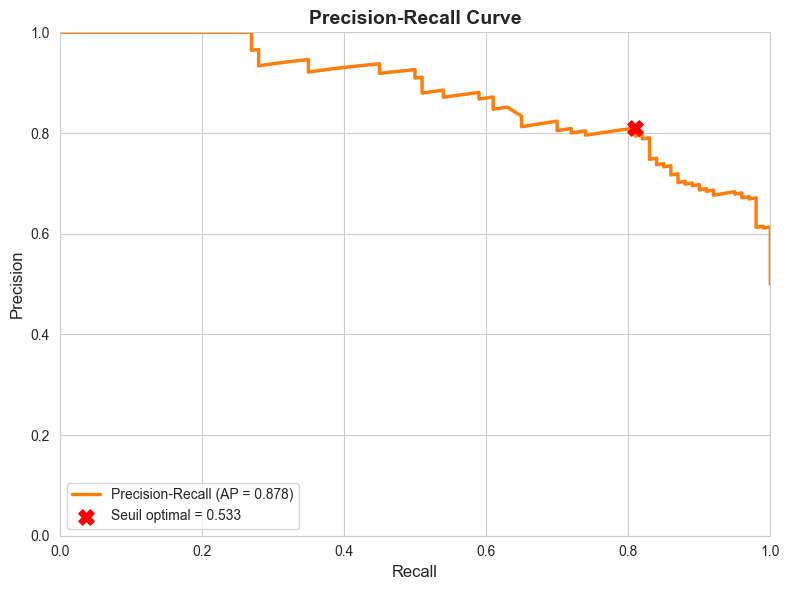

In [165]:
def display_precision_recall_curve(X, y, model):
    X_train, X_test, y_train, y_test = split_dataset(X, y)

    model_fitted = model.fit(X_train, y_train)

    y_proba = model_fitted.predict_proba(X_test)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)

    f1_scores = 2 * (precision * recall) / (precision + recall)
    optimal_idx = np.argmax(f1_scores[:-1])
    optimal_threshold = thresholds[optimal_idx]

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(
        recall,
        precision,
        color="#ff7f0e",
        linewidth=2.5,
        label=f"Precision-Recall (AP = {ap:.3f})",
    )

    ax.scatter(
        recall[optimal_idx],
        precision[optimal_idx],
        color="red",
        s=120,
        marker="X",
        label=f"Seuil optimal = {optimal_threshold:.3f}",
        zorder=3,
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title("Precision-Recall Curve", fontsize=14, fontweight="bold")
    ax.set_xlabel("Recall", fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)

    ax.legend(loc="lower left", frameon=True)

    plt.tight_layout()
    plt.show()


display_precision_recall_curve(df["review_cleaned"], df["sentiment"], BEST_MODEL)